In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Haik_Ruzan/houses_train.csv')
df

,Unnamed: 0,price,condition,district,max_floor,street,num_rooms,region,area,url,num_bathrooms,building_type,floor,ceiling_height
0,4598,100000.0,newly repaired,Arabkir,6,Kievyan St,3,Yerevan,96.0,http://www.myrealty.am/en/item/26229/3-senyaka...,1,stone,4,3.0
1,5940,52000.0,good,Arabkir,14,Mamikoniants St,3,Yerevan,78.0,http://www.myrealty.am/en/item/32897/3-senyaka...,1,panel,10,2.8
2,2302,52000.0,newly repaired,Qanaqer-Zeytun,9,M. Melikyan St,3,Yerevan,97.0,http://www.myrealty.am/en/item/1459/apartment-...,1,panel,1,2.8
3,5628,130000.0,good,Center,4,Spendiaryan St,3,Yerevan,80.0,http://www.myrealty.am/en/item/2099/3-senyakan...,1,stone,2,3.2
4,760,81600.0,zero condition,Center,9,Ler. Kamsar St,3,Yerevan,107.0,http://www.myrealty.am/en/item/22722/3-senyaka...,1,monolit,9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,3585,70000.0,newly repaired,Arabkir,5,Griboedov St,3,Yerevan,97.0,http://www.myrealty.am/en/item/36852/3-senyaka...,1,stone,4,2.8
4997,3291,77000.0,newly repaired,Arabkir,4,Orbeli Yeghbayrner St,3,Yerevan,71.0,http://www.myrealty.am/en/item/13933/Apartment...,1,stone,4,2.8
4998,5959,46000.0,zero condition,Center,5,Mashtots Ave,1,Yerevan,40.0,http://www.myrealty.am/en/item/31190/1-senyaka...,1,stone,2,3.0
4999,542,99000.0,newly repaired,Center,14,Argishti St,4,Yerevan,118.0,http://www.myrealty.am/en/item/25905/4-senyaka...,2,monolit,14,3.0


In [ ]:
df = df[(df['Unnamed: 0'] > 500) & (df['price'] < 500000)]
df = df[df['ceiling_height'] != 3.8]
df = df[df['floor'] < 20]

In [ ]:
target = np.log1p(df["price"])
features = df.drop('price', axis=1)

In [ ]:
features['Room_Density'] = features['area'] / features['num_rooms']

In [ ]:
features["is_top_floor"] = (features["max_floor"] == features["floor"]).astype(int)

In [ ]:
features = features.drop(['region', 'url', 'num_rooms', 'max_floor', 'num_bathrooms'], axis=1)

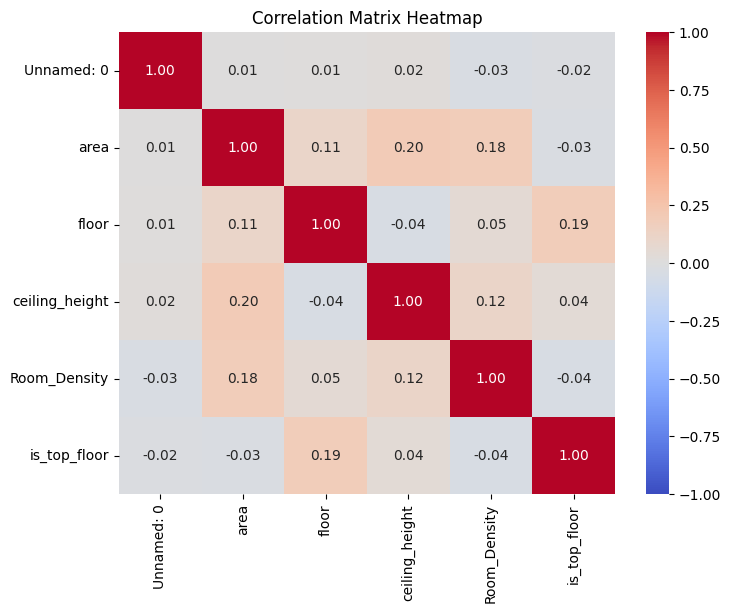

In [ ]:
corr_matrix = features.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

<Axes: xlabel='Unnamed: 0', ylabel='price'>

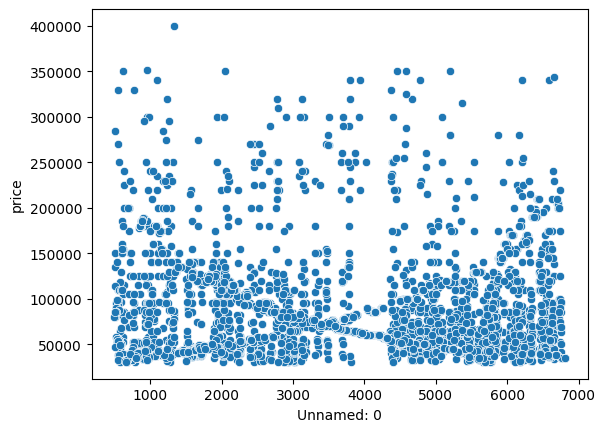

In [ ]:
sns.scatterplot(data=df, x="Unnamed: 0", y="price")

<Axes: xlabel='floor', ylabel='price'>

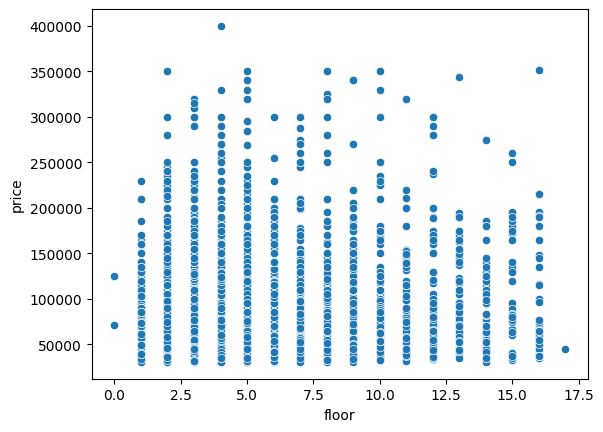

In [ ]:
sns.scatterplot(data=df, x="floor", y="price")

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from xgboost import XGBRegressor

numeric_features = [
    "area",
    "floor",
    "Unnamed: 0",
    "ceiling_height",
    "Room_Density",
    "is_top_floor"
]

categorical_features = [
    "district",
    "condition",
    "building_type"
]

street_transformer=Pipeline([
    ('target_enc', TargetEncoder())
])

model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("street",street_transformer,['street'])
])

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", model)
])

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    "model__n_estimators": [300, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [4, 6, 8],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=kf,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(features, target)

print("=" * 50)
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(grid_search.best_score_)

best_pipeline = grid_search.best_estimator_

scores = cross_validate(
    best_pipeline,
    features,
    target,
    cv=kf,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("\nMean MAE :", -scores["test_MAE"].mean())
print("Mean RMSE:", -scores["test_RMSE"].mean())
print("Mean R²  :", scores["test_R2"].mean())

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 500, 'model__subsample': 0.8}

Best Cross-Validation R²:
0.8695612681603194

Mean MAE : 0.1354719617720602
Mean RMSE: 0.18470585450404692
Mean R²  : 0.8695612681603194
